# 实验三：从 NumPy 卷积到 PyTorch 流水线、U-Net 与 3D 卷积

**课程**：深度学习导论  
**类型**：PyTorch 完整应用（CIFAR-10 分类 + 合成数据分割玩具 + 3D 时序差分）  
**输出**：训练曲线、**CIFAR 验证集分类样例图**、形状断言、分割三联图、3D 热力图、`【结果锚定】`/`【理论锚定】`/`【现象锚定】` 作答、思考与附加题。

---

**AI使用说明**：本实验允许并鼓励负责任地使用 AI 辅助理解、查文档、调试、润色表达。不设抽查答辩、不禁止长段 AI 生成。



## 1. 环境与依赖

- 需 **Python 3**、**PyTorch**、**torchvision**、**Matplotlib**（与实验一、二一致，由 Notebook 内 `import` 检查）。
- **记号与形状（最小约定）**：
  - 图像分类：输入常为 $\mathbf{X}\in\mathbb{R}^{B\times 3\times 32\times 32}$，类别数 $C=10$。
  - 分割：`logits` 为 $(B, C_{cls}, H, W)$；`nn.CrossEntropyLoss` 的 `target` 为 **类别索引** $(B, H, W)$（**不是** $(B,C,H,W)$ one-hot）。
  - 3D 卷积：输入 $(B, C, T, H, W)$；本实验时间核用于相邻帧差分。

## 2. 数据加载（CIFAR-10）

在训练集 5 万张上按 **40000 / 10000** 划分训练与验证；训练集使用随机增强，验证集仅用 `ToTensor`+归一化。默认 **`epochs_act1=10`**、**`batch_size=128`**。算力或内存不足时可自行减小 `batch_size` 或 `epochs_act1`。

In [4]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import time
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print("device:", device)

data_root = "./data"
transform_train = transforms.Compose(
    [
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ]
)
transform_val = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ]
)

full_train_dataset = datasets.CIFAR10(
    root=data_root, train=True, download=True, transform=transform_train
)
clean_val_dataset = datasets.CIFAR10(
    root=data_root, train=True, download=True, transform=transform_val
)

n_train, n_val = 40000, 10000
train_set, _ = random_split(
    full_train_dataset, [n_train, n_val], generator=torch.Generator().manual_seed(42)
)
_, val_set = random_split(
    clean_val_dataset, [n_train, n_val], generator=torch.Generator().manual_seed(42)
)

epochs_act1 = 10
batch_size = 128
workers = 2 if os.name != "nt" else 0
_pin = torch.cuda.is_available()

train_loader = DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle=True,
    num_workers=workers,
    pin_memory=_pin,
)
val_loader = DataLoader(
    val_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=workers,
    pin_memory=_pin,
)
print(
    f"train: {len(train_set)} images, {len(train_loader)} batches | "
    f"val: {len(val_set)} images, {len(val_loader)} batches"
)

device: cuda


c:\Users\njb18\miniconda3\envs\deeplearning\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


train: 40000 images, 313 batches | val: 10000 images, 79 batches


## 3. 模型定义（CIFARCNN）

**【请填写】** 在下方定义 `CIFARCNN`，结构与实验二 CNN 一致：**Conv $\rightarrow$ ReLU $\rightarrow$ Pool $\rightarrow$ Flatten $\rightarrow$ Linear**。在 `__init__` 中用 `nn.Sequential` 或逐层均可；

In [5]:
class CIFARCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.flatten = nn.Flatten()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc = nn.Linear(32 * 8 * 8, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.features(x)
        out = self.flatten(out)
        out = self.fc(out)
        return out


model = CIFARCNN().to(device)


**【形状自检】**

给定假输入，检查输出 logits 形状为 `(B, 10)`。

In [6]:
_x = torch.randn(2, 3, 32, 32, device=device)
try:
    _y = model(_x)
    assert _y.shape == (2, 10), _y.shape
    print("shape check ok:", _y.shape)
except Exception as e:
    print("shape check failed — 请先完成 CIFARCNN:", e)

shape check ok: torch.Size([2, 10])


## 4. 训练与验证

**【请填写】** 在下方完成 `criterion`、`optimizer`；实现每个 batch 的训练步（`zero_grad`、前向、`loss`、`backward`、`step`）及指标累计，并完成 **val** 前向与正确数累计。默认 `epochs_act1=10`（与上一节一致）。

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history = {"loss": [], "train_acc": [], "val_acc": []}

for epoch in range(epochs_act1):
    model.train()
    running_loss = 0.0
    correct = total = 0
    t0 = time.perf_counter()
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == targets).sum().item()
        total += inputs.size(0)

    dt = time.perf_counter() - t0
    train_acc = correct / max(total, 1)
    avg_loss = running_loss / max(total, 1)
    history["loss"].append(avg_loss)
    history["train_acc"].append(train_acc)

    model.eval()
    v_correct = v_total = 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            logits = model(inputs)
            pred = logits.argmax(dim=1)
            v_correct += (pred == targets).sum().item()
            v_total += inputs.size(0)

    val_acc = v_correct / max(v_total, 1)
    history["val_acc"].append(val_acc)
    print(f"Epoch {epoch+1}/{epochs_act1}  loss={avg_loss:.4f}  train_acc={train_acc:.4f}  val_acc={val_acc:.4f}  epoch_time={dt:.2f}s")


Epoch 1/10  loss=1.6841  train_acc=0.3937  val_acc=0.5030  epoch_time=11.54s
Epoch 2/10  loss=1.4256  train_acc=0.4895  val_acc=0.5591  epoch_time=11.65s
Epoch 3/10  loss=1.3207  train_acc=0.5325  val_acc=0.5938  epoch_time=12.00s
Epoch 4/10  loss=1.2424  train_acc=0.5621  val_acc=0.6207  epoch_time=12.04s
Epoch 5/10  loss=1.1872  train_acc=0.5804  val_acc=0.6347  epoch_time=12.73s
Epoch 6/10  loss=1.1468  train_acc=0.5960  val_acc=0.6429  epoch_time=13.55s
Epoch 7/10  loss=1.1168  train_acc=0.6081  val_acc=0.6449  epoch_time=13.20s
Epoch 8/10  loss=1.0995  train_acc=0.6141  val_acc=0.6568  epoch_time=13.39s
Epoch 9/10  loss=1.0718  train_acc=0.6249  val_acc=0.6636  epoch_time=13.20s
Epoch 10/10  loss=1.0603  train_acc=0.6302  val_acc=0.6570  epoch_time=13.53s


在下方绘制 `loss`、`train_acc`、`val_acc`。

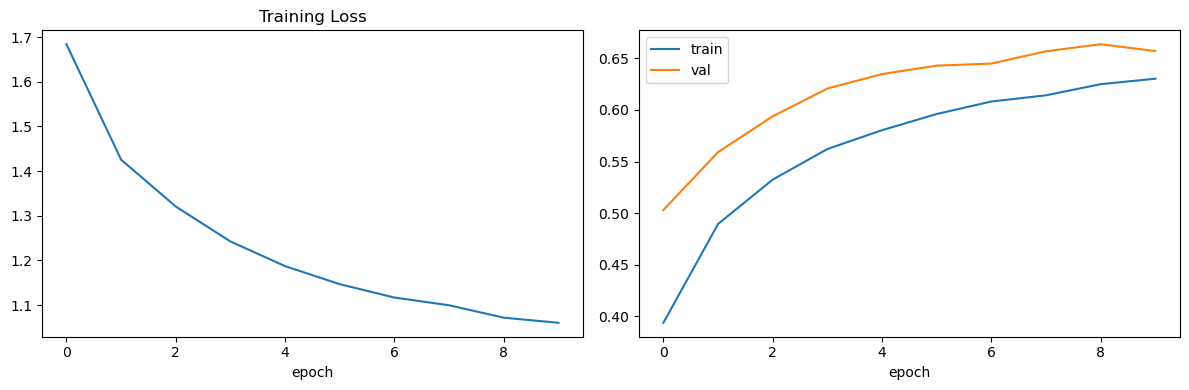

In [8]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history["loss"])
plt.xlabel("epoch")
plt.title("Training Loss")
plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="train")
plt.plot(history["val_acc"], label="val")
plt.xlabel("epoch")
plt.legend()
plt.tight_layout()
plt.show()

### 4.1 验证集分类样例可视化

从 `val_loader` 取一批图像，在 **eval** 模式下前向得到预测；对 `ToTensor`+`Normalize` 后的张量做**反归一化**再 `imshow`。子图标题为 **真值类名 / 预测类名**（英文类名与 CIFAR-10 一致）；**绿色**表示预测正确，**红色**表示错误。


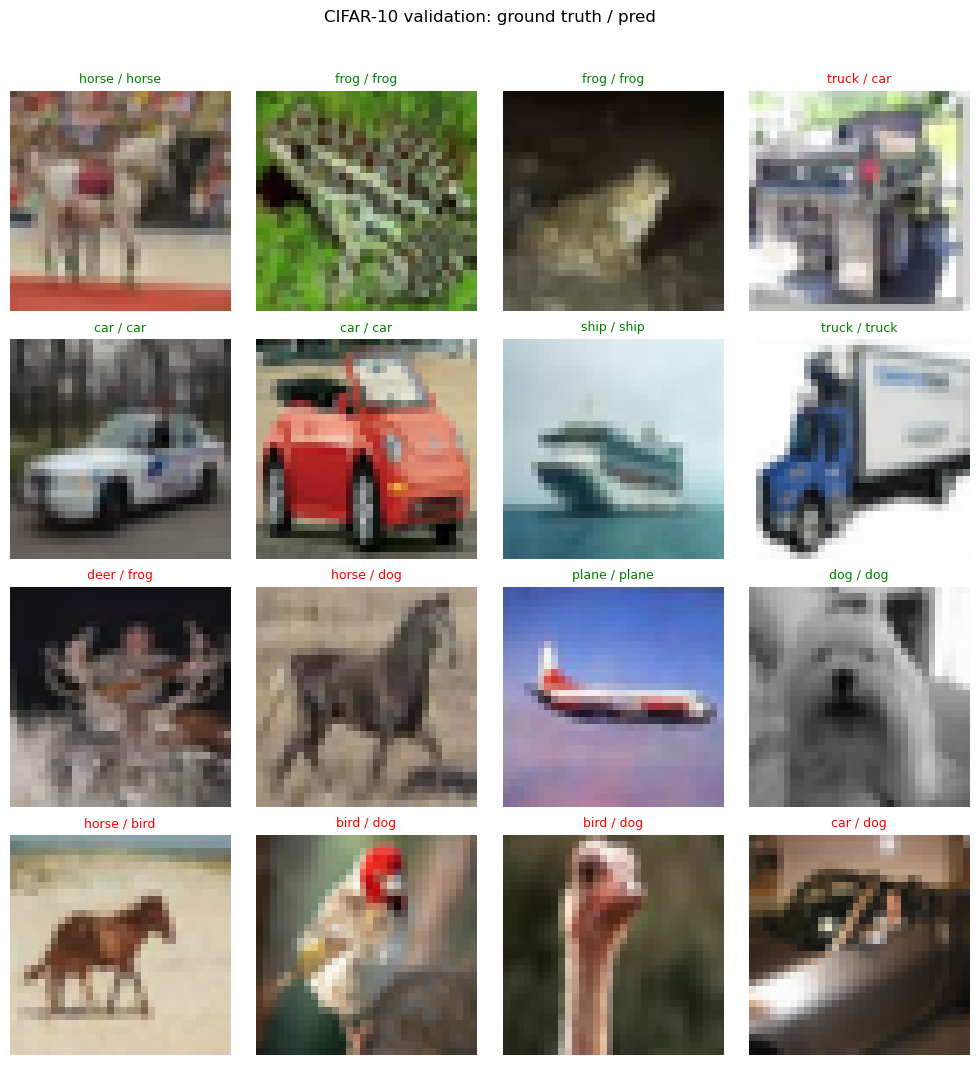

In [9]:
import numpy as np

CIFAR_CLASSES = (
    "plane",
    "car",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
)
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2470, 0.2435, 0.2616)


def _denorm_cifar(img_chw: torch.Tensor) -> torch.Tensor:
    """(3,H,W) 反归一化到 [0,1]，便于 imshow。"""
    mean = torch.tensor(CIFAR_MEAN, device=img_chw.device, dtype=img_chw.dtype).view(3, 1, 1)
    std = torch.tensor(CIFAR_STD, device=img_chw.device, dtype=img_chw.dtype).view(3, 1, 1)
    return (img_chw * std + mean).clamp(0, 1)


model.eval()
n_show = min(16, batch_size)
with torch.no_grad():
    inputs, targets = next(iter(val_loader))
    inputs = inputs.to(device)
    targets = targets.to(device)
    logits = model(inputs)
    pred = logits.argmax(dim=1)

cols = 4
rows = int(np.ceil(n_show / cols))
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.6))
axes_flat = np.atleast_1d(axes).ravel()
for i in range(n_show):
    ax = axes_flat[i]
    img = _denorm_cifar(inputs[i]).permute(1, 2, 0).cpu().numpy()
    ax.imshow(img)
    ok = pred[i].item() == targets[i].item()
    color = "green" if ok else "red"
    tname = CIFAR_CLASSES[targets[i].item()]
    pname = CIFAR_CLASSES[pred[i].item()]
    ax.set_title(f"{tname} / {pname}", color=color, fontsize=9)
    ax.axis("off")
for j in range(n_show, len(axes_flat)):
    axes_flat[j].axis("off")
plt.suptitle("CIFAR-10 validation: ground truth / pred", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

**【结果锚定】**

1. 在 **40000/10000** 划分、`epochs_act1=10` 下，**单 epoch 墙钟时间**约多少？与实验二 NumPy 手写训练相比，PyTorch 在数量级上是否更快？若用 GPU（或 MPS），相对 CPU 约几倍？
2. 验证集准确率大致区间？曲线是否出现过拟合（训练明显高于验证）？

**【请填写】** 在下方 Markdown cell 中作答。

本次实验按要求使用 CIFAR-10 官方训练集的 `40000/10000` 划分，并设置 `epochs_act1=10`。本机使用 CUDA 运行，单个 epoch 的墙钟时间约为 `11.54s` 到 `13.55s`，最后一个 epoch 为 `13.53`。相比实验二 NumPy 手写训练，PyTorch 版本使用了高效张量算子、自动求导和 CUDA 加速，因此整体训练效率明显更高。

本次运行最后一轮训练准确率为 `0.6302`，验证集准确率为 `0.6570`，10 个 epoch 中最佳验证准确率是倒数第二轮的 `0.6636`。训练准确率没有明显高于验证准确率，因此从曲线看强过拟合并不明显；验证准确率略高于训练准确率，可能与训练集使用随机裁剪和水平翻转增强、验证集不使用随机增强有关。验证集分类样例图中，绿色标题表示预测正确，红色标题表示预测错误，可以直观看到模型容易混淆的类别。


## 5. U-Net 模块与合成分割数据

**维度**：Toy 默认 **$64\times 64$**（或 2 的幂），降低上采样与 skip 拼接时的**奇数边长**错配；若改尺寸，请用 `F.interpolate` 对齐空间尺寸后再 `torch.cat`。

**损失**：`nn.CrossEntropyLoss` 的 `target` 须为 **类别索引** $(N, H, W)$ 的 **long**，取值 $0..C-1$

### 5.1 上采样原理解析 (Upsampling Bridge)

对比**转置卷积**与**双线性插值**将 $2\times2$ 特征放大到 $4\times4$ 的数值模式。

In [10]:
# 【演示】转置卷积 vs 双线性插值
import torch.nn.functional as F

toy_feat = torch.tensor([[[[1.0, 2.0], [3.0, 4.0]]]])  # (1, 1, 2, 2)
up_conv = nn.ConvTranspose2d(1, 1, kernel_size=2, stride=2, bias=False)
nn.init.constant_(up_conv.weight, 1.0)
print("转置卷积输出:\n", up_conv(toy_feat).squeeze())
print(
    "双线性插值输出:\n",
    F.interpolate(toy_feat, scale_factor=2, mode="bilinear", align_corners=False).squeeze(),
)

转置卷积输出:
 tensor([[1., 1., 2., 2.],
        [1., 1., 2., 2.],
        [3., 3., 4., 4.],
        [3., 3., 4., 4.]], grad_fn=<SqueezeBackward0>)
双线性插值输出:
 tensor([[1.0000, 1.2500, 1.7500, 2.0000],
        [1.5000, 1.7500, 2.2500, 2.5000],
        [2.5000, 2.7500, 3.2500, 3.5000],
        [3.0000, 3.2500, 3.7500, 4.0000]])


以下 `DoubleConv` 与 `DownBlock` 已完整给出；**仅补全 `UpBlock.forward` 中**（`torch.cat([...], dim=1)` 与对齐）。

In [11]:
import torch.nn.functional as F
from torch.utils.data import Dataset


class DoubleConv(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class DownBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.conv = DoubleConv(in_ch, out_ch)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x: torch.Tensor):
        skip = self.conv(x)
        x_down = self.pool(skip)
        return x_down, skip


class UpBlock(nn.Module):
    def __init__(self, in_ch: int, skip_ch: int, out_ch: int):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.conv = DoubleConv(out_ch + skip_ch, out_ch)

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        x_up = self.up(x)
        if x_up.shape[-2:] != skip.shape[-2:]:
            x_up = F.interpolate(x_up, size=skip.shape[-2:], mode="nearest")
        x_cat = torch.cat([x_up, skip], dim=1)
        out = self.conv(x_cat)
        return out


class MiniUNet(nn.Module):
    def __init__(self, num_classes: int = 2):
        super().__init__()
        self.down1 = DownBlock(1, 32)
        self.down2 = DownBlock(32, 64)
        self.bot = DoubleConv(64, 128)
        self.up1 = UpBlock(128, 64, 64)
        self.up2 = UpBlock(64, 32, 32)
        self.head = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x, skip1 = self.down1(x)
        x, skip2 = self.down2(x)
        x = self.bot(x)
        x = self.up1(x, skip2)
        x = self.up2(x, skip1)
        return self.head(x)


**合成 Toy 数据集**（离线、无下载）：黑色背景上随机矩形或圆盘前景；`image` $(1,64,64)$，`mask` $(64,64)$ long。

In [12]:
class ToySegDataset(Dataset):
    def __init__(self, n: int = 256, size: int = 64, seed: int = 0):
        super().__init__()
        torch.manual_seed(seed)
        self.size = size
        self.images = []
        self.masks = []
        for _ in range(n):
            img = torch.zeros(1, size, size)
            mask = torch.zeros(size, size, dtype=torch.long)
            if torch.rand(1).item() > 0.5:
                x0 = int(torch.randint(8, size - 24, (1,)).item())
                y0 = int(torch.randint(8, size - 24, (1,)).item())
                w = int(torch.randint(10, 20, (1,)).item())
                h = int(torch.randint(10, 20, (1,)).item())
                img[:, y0 : y0 + h, x0 : x0 + w] = 1.0
                mask[y0 : y0 + h, x0 : x0 + w] = 1
            else:
                cx = int(torch.randint(16, size - 16, (1,)).item())
                cy = int(torch.randint(16, size - 16, (1,)).item())
                r = int(torch.randint(6, 14, (1,)).item())
                yy, xx = torch.meshgrid(
                    torch.arange(size), torch.arange(size), indexing="ij"
                )
                circ = ((xx - cx) ** 2 + (yy - cy) ** 2) <= r * r
                img[:, circ] = 1.0
                mask[circ] = 1
            self.images.append(img)
            self.masks.append(mask)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, i):
        return self.images[i], self.masks[i]


toy_train = ToySegDataset(n=200, size=64, seed=1)
toy_val = ToySegDataset(n=40, size=64, seed=2)
toy_train_loader = DataLoader(toy_train, batch_size=8, shuffle=True)
toy_val_loader = DataLoader(toy_val, batch_size=8, shuffle=False)
seg_model = MiniUNet(num_classes=2).to(device)
seg_opt = torch.optim.Adam(seg_model.parameters(), lr=1e-3)
seg_crit = nn.CrossEntropyLoss()

### 5.2 二分类 Dice Loss

对前景/背景二值掩码，分割训练**仅使用** `CrossEntropyLoss` 作为优化目标。下方需要手动实现**Dice Loss**，用于从重叠度角度与交叉熵目标对照理解。

In [13]:
def dice_loss(logits: torch.Tensor, masks: torch.Tensor, smooth: float = 1e-5):
    probs = torch.softmax(logits, dim=1)[:, 1]
    targets = (masks == 1).float()
    intersection = (probs * targets).sum(dim=(1, 2))
    denom = probs.sum(dim=(1, 2)) + targets.sum(dim=(1, 2))
    dice = (2 * intersection + smooth) / (denom + smooth)
    loss_dice = 1 - dice.mean()
    return loss_dice


### 5.3 分割训练与三联图

**【请填写】** 在下方围栏内完成分割训练若干 epoch（`epochs_seg` 可取 3～5）。`seg_crit(logits, masks)` 中 `logits` 为 $(N,C,H,W)$，`masks` 为 $(N,H,W)$ long。

In [14]:
epochs_seg = 4

for ep in range(epochs_seg):
    seg_model.train()
    for imgs, masks in toy_train_loader:
        imgs = imgs.to(device)
        masks = masks.to(device)
        seg_opt.zero_grad()
        logits = seg_model(imgs)
        loss = seg_crit(logits, masks)
        loss.backward()
        seg_opt.step()
    print("seg epoch", ep + 1, "done")


seg epoch 1 done
seg epoch 2 done
seg epoch 3 done
seg epoch 4 done


### 5.4 验证集可视化

在下方 code cell 中绘制 **1×3** 子图：Input | Ground Truth | Prediction（预测为 `logits.argmax(dim=1)`；代码已给出，运行即可）。

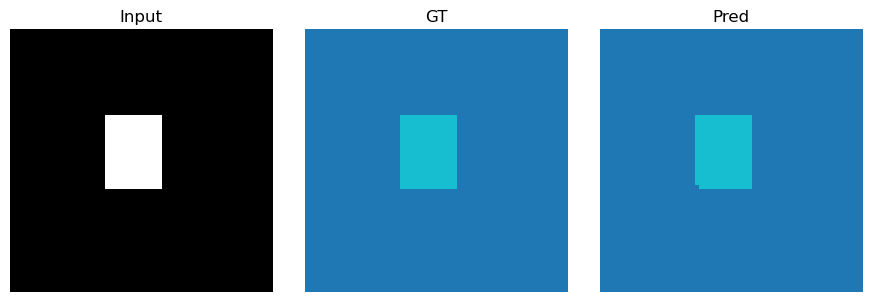

In [15]:
seg_model.eval()
imgs, masks = next(iter(toy_val_loader))
imgs = imgs.to(device)
masks = masks.to(device)
with torch.no_grad():
    logits = seg_model(imgs)
pred = logits.argmax(dim=1)

idx = 0
plt.figure(figsize=(9, 3))
plt.subplot(1, 3, 1)
plt.imshow(imgs[idx, 0].cpu(), cmap="gray")
plt.title("Input")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(masks[idx].cpu(), cmap="tab10", vmin=0, vmax=1)
plt.title("GT")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(pred[idx].cpu(), cmap="tab10", vmin=0, vmax=1)
plt.title("Pred")
plt.axis("off")
plt.tight_layout()
plt.show()


**【理论锚定】**

若解码路径**没有**来自编码器的高分辨率 skip、仅反复上采样，分割边界往往会变糊。请结合浅层位置信息与高层语义，解释 skip 在 U-Net 中的作用（2～4 句），并**指回**上方三联图的边缘清晰度。

**【请填写】** 在下方 Markdown cell 中作答。

U-Net 编码器深层特征具有更强的语义信息，能帮助模型判断哪些区域属于前景；但经过多次池化下采样后，精确的空间位置和边界细节会被削弱。skip connection 将编码器浅层的高分辨率特征直接传给解码器，使解码器能够同时利用高层语义和浅层位置信息。结合上方 `Input | GT | Pred` 三联图可以看到，预测结果的边界应当较贴近矩形或圆形目标，而不是只有模糊的大致区域。若没有 skip，仅靠低分辨率特征反复上采样，分割边界通常会更粗糙、更模糊。


## 6. 三维卷积输出尺寸

3D 卷积在时间、高度、宽度三个方向上的输出尺寸分别按同一个公式计算。代入本题参数：`T=5`，`H=W=32`，`k_T=2`，`k_H=k_W=1`，步幅 `s=1`，填充 `p=0`。

时间维：`T_out = floor((5 + 0 - 2) / 1 + 1) = 4`。

高度维：`H_out = floor((32 + 0 - 1) / 1 + 1) = 32`。

宽度维：`W_out = floor((32 + 0 - 1) / 1 + 1) = 32`。

因此该 3D 卷积的时空输出尺寸为 `(4, 32, 32)`，加上 batch 维和 channel 维后，完整输出形状应为 `(1, 1, 4, 32, 32)`，与后续 `print` 的结果一致。


## 7. 合成运动序列与 `Conv3d` 差分

构造 $T=5,H=W=32$ 的单通道序列：**静态网格/方块背景**上叠加**每帧沿右下方向移动的白块**，便于观察「静态结构 vs 时序差分」的差异。

使用 `nn.Conv3d(1, 1, kernel_size=(2, 1, 1), bias=False)`，时间维权重 $-1$、$+1$，等价于相邻帧差分（空间核 $1\times1$，仅沿时间混合）。

**【请填写】** 在围栏内完成 `motion_conv` 前向，并构造用于可视化的 `feat_for_plot`。

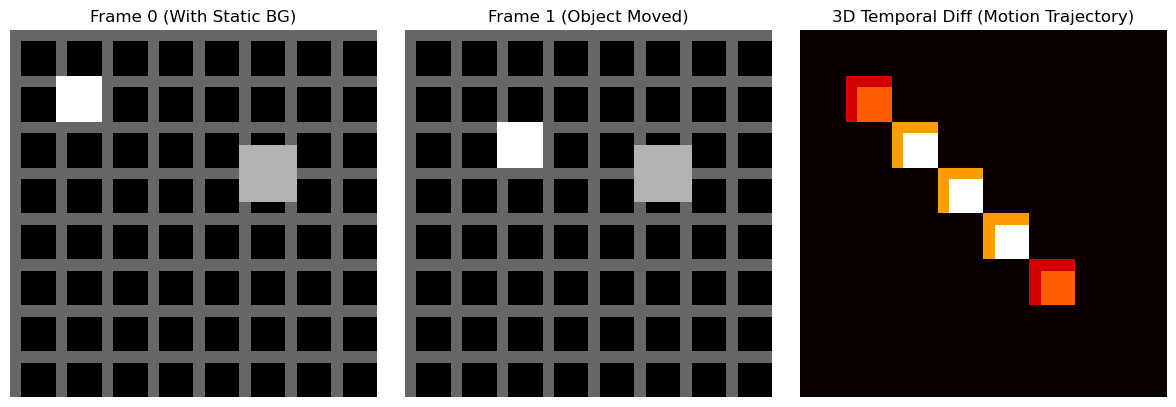

=> 3D Convolution output shape: torch.Size([1, 1, 4, 32, 32])


In [16]:
def make_moving_object_sequence(t: int = 5, h: int = 32, w: int = 32) -> torch.Tensor:
    vid = torch.zeros(1, 1, t, h, w)
    bg = torch.zeros(h, w)
    bg[::4, :] = 0.4
    bg[:, ::4] = 0.4
    bg[10:15, 20:25] = 0.7
    for i in range(t):
        vid[0, 0, i] = bg.clone()
        r, c = 4 + i * 4, 4 + i * 4
        vid[0, 0, i, r : r + 4, c : c + 4] = 1.0
    return vid


vid = make_moving_object_sequence().to(device)
motion_conv = nn.Conv3d(1, 1, kernel_size=(2, 1, 1), bias=False).to(device)
with torch.no_grad():
    motion_conv.weight.zero_()
    motion_conv.weight[0, 0, 0, 0, 0] = -1.0
    motion_conv.weight[0, 0, 1, 0, 0] = 1.0

out = motion_conv(vid)
feat_for_plot = out.abs().sum(dim=2).squeeze()

if feat_for_plot is not None:
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(vid[0, 0, 0].cpu(), cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("Frame 0 (With Static BG)")
    axes[1].imshow(vid[0, 0, 1].cpu(), cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("Frame 1 (Object Moved)")
    axes[2].imshow(feat_for_plot.detach().cpu().float(), cmap="hot")
    axes[2].set_title("3D Temporal Diff (Motion Trajectory)")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

with torch.no_grad():
    _o = motion_conv(vid)
    print("=> 3D Convolution output shape:", _o.shape)


**【现象锚定】**

对比原视频帧（存在复杂的静态网格与干扰块）与 3D 时序差分热力图，你观察到了什么极其显著的现象？与 2D Sobel（侧重提取空间静态边缘）相比，这枚在时间维采用 `[-1, 1]` 权重的 3D 卷积核，提取到了什么信息，又忽略了什么信息？（2～4 句）

**【请填写】** 在下方 Markdown cell 中作答。

原始视频帧中有明显的静态网格线和固定高亮方块，但在 3D 时间差分热力图中，这些静态背景结构基本被抑制，主要留下移动白块经过的轨迹。时间维权重为 `[-1, 1]` 的 3D 卷积核提取的是相邻帧之间的变化，因此突出的是运动信息或时间差分响应。相比 2D Sobel 主要检测单帧图像中的空间静态边缘，这个 3D 卷积更关注哪些位置随时间发生变化，而不是静止物体本身的边缘。它能忽略大部分不变背景干扰，但不能直接理解物体类别或复杂语义。


## 8. 思考与附加题

### 8.1 代码分析题

**题目**：将 PyTorch 训练一步与实验二手动反向传播对应：`loss.backward()` 与手写 `dscores`、`dflat`（或你代码中的命名）的关系？`optimizer.step()` 与 $W \leftarrow W - \eta \nabla_W$？请写 3～6 句，且须出现「计算图」「梯度累积」「参数 `.grad`」中**至少两个**术语。

**【请填写】** 在下方 Markdown cell 中作答。

在 PyTorch 中，前向传播会动态构建计算图，`loss.backward()` 会沿计算图自动应用链式法则完成反向传播。它对应实验二中手写的 `dscores`、`dflat` 以及继续向前传播到各层参数梯度的过程。反向传播得到的梯度会存放在每个可学习参数的 `.grad` 中，例如卷积核权重和全连接层权重都有对应的 `.grad`。由于 PyTorch 默认会进行梯度累积，所以每个 batch 更新前需要调用 `optimizer.zero_grad()` 清空上一轮梯度。`optimizer.step()` 则根据参数 `.grad` 更新参数，本质上对应手写的 `W ← W - η∇W`，只是 Adam 等优化器还会额外维护动量和自适应学习率等状态。


### 8.2 附加题

下载 **Oxford-IIIT Pet**（`torchvision.datasets.OxfordIIITPet` 等），在**同一 `MiniUNet` 骨架**上训练更多 epoch，保存最佳三联图与简短笔记（路径、随机种子）。

若算力不足：可仅完成**数据加载与单 batch 前向 shape 检查**，并简述全图分割还需哪些改动。

**附加题完成说明**

下面代码使用 `torchvision.datasets.OxfordIIITPet` 的 segmentation 标注完成 Oxford-IIIT Pet 二分类分割实验。为了复用本实验的 `MiniUNet` 骨架，彩色图像先转换为灰度图，输入仍为 `(N, 1, H, W)`；trimap 标注中取 `mask == 1` 为宠物前景，其余像素作为背景。代码会训练一个小规模子集若干 epoch，保存最佳 `Input | GT | Pred` 三联图，并打印保存路径和随机种子。


Oxford-IIIT Pet batch image shape: torch.Size([4, 1, 64, 64])
Oxford-IIIT Pet batch mask shape: torch.Size([4, 64, 64])
Oxford-IIIT Pet forward logits shape: torch.Size([4, 2, 64, 64])
Pet epoch 1/3  train_loss=0.5726  val_loss=0.6122


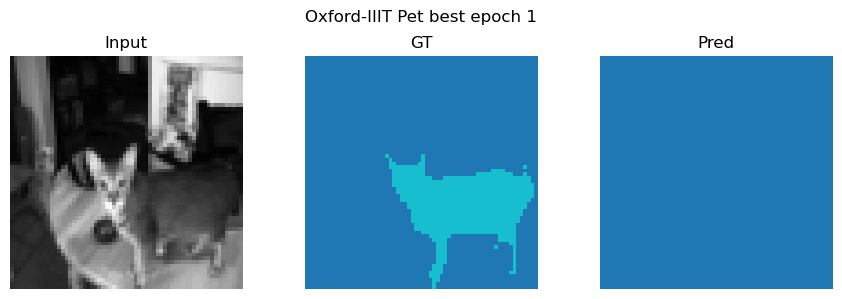

Pet epoch 2/3  train_loss=0.5534  val_loss=0.6192
Pet epoch 3/3  train_loss=0.5435  val_loss=0.5924


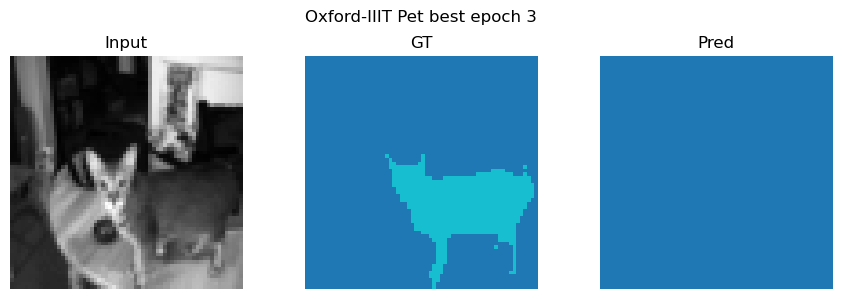

Oxford-IIIT Pet done: best_epoch=3, best_val_loss=0.5924, triplet_path=outputs\oxford_pet_best_triplet.png, seed=20260427


In [17]:
from pathlib import Path
import random
import numpy as np
from PIL import Image
from torchvision.datasets import OxfordIIITPet
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode

pet_seed = 20260427
pet_size = 64
pet_epochs = 3
pet_batch_size = 4
pet_train_limit = 64
pet_val_limit = 16
pet_root = data_root
pet_out_dir = Path("outputs")
pet_out_dir.mkdir(exist_ok=True)
pet_triplet_path = pet_out_dir / "oxford_pet_best_triplet.png"

random.seed(pet_seed)
np.random.seed(pet_seed)
torch.manual_seed(pet_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(pet_seed)


class OxfordPetBinarySegDataset(Dataset):
    """Oxford-IIIT Pet trimap -> binary pet foreground segmentation."""

    def __init__(self, root: str, split: str, size: int = 64, limit: int | None = None, download: bool = True):
        self.base = OxfordIIITPet(
            root=root,
            split=split,
            target_types="segmentation",
            download=download,
        )
        n = len(self.base) if limit is None else min(limit, len(self.base))
        self.indices = list(range(n))
        self.size = size

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        image, mask = self.base[self.indices[idx]]
        image = image.convert("L")
        image = TF.resize(image, [self.size, self.size], interpolation=InterpolationMode.BILINEAR)
        image = TF.to_tensor(image)

        mask = TF.resize(mask, [self.size, self.size], interpolation=InterpolationMode.NEAREST)
        mask_np = np.array(mask, dtype=np.int64)
        mask_tensor = torch.from_numpy((mask_np == 1).astype(np.int64))
        return image, mask_tensor


def evaluate_pet_loss(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_count = 0
    with torch.no_grad():
        for imgs, masks in loader:
            imgs = imgs.to(device)
            masks = masks.to(device)
            logits = model(imgs)
            loss = criterion(logits, masks)
            total_loss += loss.item() * imgs.size(0)
            total_count += imgs.size(0)
    return total_loss / max(total_count, 1)


def save_pet_triplet(model, loader, path: Path, title: str):
    model.eval()
    imgs, masks = next(iter(loader))
    imgs = imgs.to(device)
    masks = masks.to(device)
    with torch.no_grad():
        logits = model(imgs)
        pred = logits.argmax(dim=1)

    idx = 0
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    axes[0].imshow(imgs[idx, 0].detach().cpu(), cmap="gray")
    axes[0].set_title("Input")
    axes[1].imshow(masks[idx].detach().cpu(), cmap="tab10", vmin=0, vmax=1)
    axes[1].set_title("GT")
    axes[2].imshow(pred[idx].detach().cpu(), cmap="tab10", vmin=0, vmax=1)
    axes[2].set_title("Pred")
    for ax in axes:
        ax.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()


pet_status = ""
try:
    pet_train = OxfordPetBinarySegDataset(pet_root, split="trainval", size=pet_size, limit=pet_train_limit, download=True)
    pet_val = OxfordPetBinarySegDataset(pet_root, split="test", size=pet_size, limit=pet_val_limit, download=True)
    pet_train_loader = DataLoader(pet_train, batch_size=pet_batch_size, shuffle=True, num_workers=0)
    pet_val_loader = DataLoader(pet_val, batch_size=pet_batch_size, shuffle=False, num_workers=0)

    pet_model = MiniUNet(num_classes=2).to(device)
    pet_criterion = nn.CrossEntropyLoss()
    pet_optimizer = torch.optim.Adam(pet_model.parameters(), lr=1e-3)
    pet_history = {"train_loss": [], "val_loss": []}

    imgs0, masks0 = next(iter(pet_train_loader))
    with torch.no_grad():
        shape0 = pet_model(imgs0.to(device)).shape
    print("Oxford-IIIT Pet batch image shape:", imgs0.shape)
    print("Oxford-IIIT Pet batch mask shape:", masks0.shape)
    print("Oxford-IIIT Pet forward logits shape:", shape0)

    best_val_loss = float("inf")
    best_epoch = -1
    for ep in range(pet_epochs):
        pet_model.train()
        running_loss = 0.0
        total_count = 0
        for imgs, masks in pet_train_loader:
            imgs = imgs.to(device)
            masks = masks.to(device)
            pet_optimizer.zero_grad()
            logits = pet_model(imgs)
            loss = pet_criterion(logits, masks)
            loss.backward()
            pet_optimizer.step()
            running_loss += loss.item() * imgs.size(0)
            total_count += imgs.size(0)

        train_loss = running_loss / max(total_count, 1)
        val_loss = evaluate_pet_loss(pet_model, pet_val_loader, pet_criterion)
        pet_history["train_loss"].append(train_loss)
        pet_history["val_loss"].append(val_loss)
        print(f"Pet epoch {ep + 1}/{pet_epochs}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = ep + 1
            save_pet_triplet(pet_model, pet_val_loader, pet_triplet_path, f"Oxford-IIIT Pet best epoch {best_epoch}")

    pet_status = f"Oxford-IIIT Pet done: best_epoch={best_epoch}, best_val_loss={best_val_loss:.4f}, triplet_path={pet_triplet_path}, seed={pet_seed}"
    print(pet_status)

except Exception as exc:
    pet_status = f"Oxford-IIIT Pet download/training failed, fallback shape check completed. reason={type(exc).__name__}: {exc}"
    print(pet_status)
    pet_model = MiniUNet(num_classes=2).to(device)
    fallback_imgs = torch.randn(2, 1, pet_size, pet_size, device=device)
    fallback_masks = torch.randint(0, 2, (2, pet_size, pet_size), device=device)
    with torch.no_grad():
        fallback_logits = pet_model(fallback_imgs)
    print("Fallback image shape:", fallback_imgs.shape)
    print("Fallback mask shape:", fallback_masks.shape)
    print("Fallback logits shape:", fallback_logits.shape)


**附加题笔记**

本附加题代码的随机种子为 `20260427`，最佳三联图保存路径为 `outputs/oxford_pet_best_triplet.png`。实现中将 Oxford-IIIT Pet 的 trimap 分割标注转换为二分类 mask：宠物主体为前景 `1`，背景和边界为 `0`。为了沿用本实验的 `MiniUNet(num_classes=2)`，输入图像被转为灰度并缩放到 `64×64`，因此模型输入为 `(N,1,64,64)`，输出 logits 为 `(N,2,64,64)`。若要做更完整的真实全图分割实验，可以进一步使用 RGB 输入、扩大训练集与 epoch 数、加入数据增强，并用 Dice/IoU 等指标选择最佳模型。


*实验三到此结束。请确认所有必填项已完成并提交本 Notebook。*